In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
# PROBLEM 4(a)(i)
# Load the dataset
data = pd.read_csv('data/question_4_data.csv')

print("Shape of the dataset:", data.shape)
print("----")
print("Datatypes: \n", data.dtypes)
print("----")
print(data.describe())
print("----")
print("Number of samples: " + str(len(data)))
print("Number of features: " + str(len(data.columns) - 1))  # Exclude the target variable
print("Are there missing values? " + str(data.isnull().values.any()))

Shape of the dataset: (1030, 9)
----
Datatypes: 
 cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object
----
            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.400000   200.100000   

Mean:  35.817961165048544
Standard Deviation:  16.705741961912512


'\n - This distribution is skewed to the right, with a long tail towards higher values.\n - Most of the data is to the left (between 10 and 40 MPa).\n - The mean and standard deviation are reported below (35.8 and 16.7, respectively).\n'

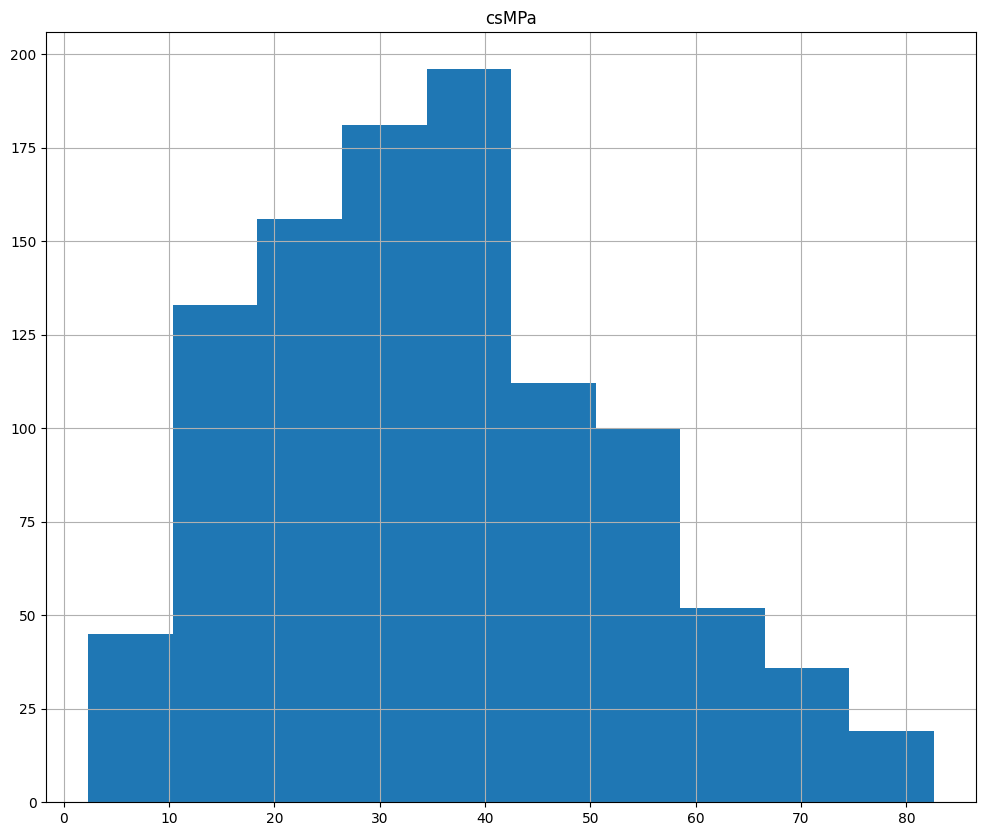

In [14]:
data.hist(column='csMPa', figsize=(12, 10))
mean_value = data['csMPa'].mean()
std_value = data['csMPa'].std()
print("Mean: ", mean_value)
print("Standard Deviation: ", std_value)
"""
 - This distribution is skewed to the right, with a long tail towards higher values.
 - Most of the data is to the left (between 10 and 40 MPa).
 - The mean and standard deviation are reported below (35.8 and 16.7, respectively).
"""

array([[<Axes: title={'center': 'cement'}>,
        <Axes: title={'center': 'slag'}>,
        <Axes: title={'center': 'flyash'}>],
       [<Axes: title={'center': 'water'}>,
        <Axes: title={'center': 'superplasticizer'}>,
        <Axes: title={'center': 'coarseaggregate'}>],
       [<Axes: title={'center': 'fineaggregate'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

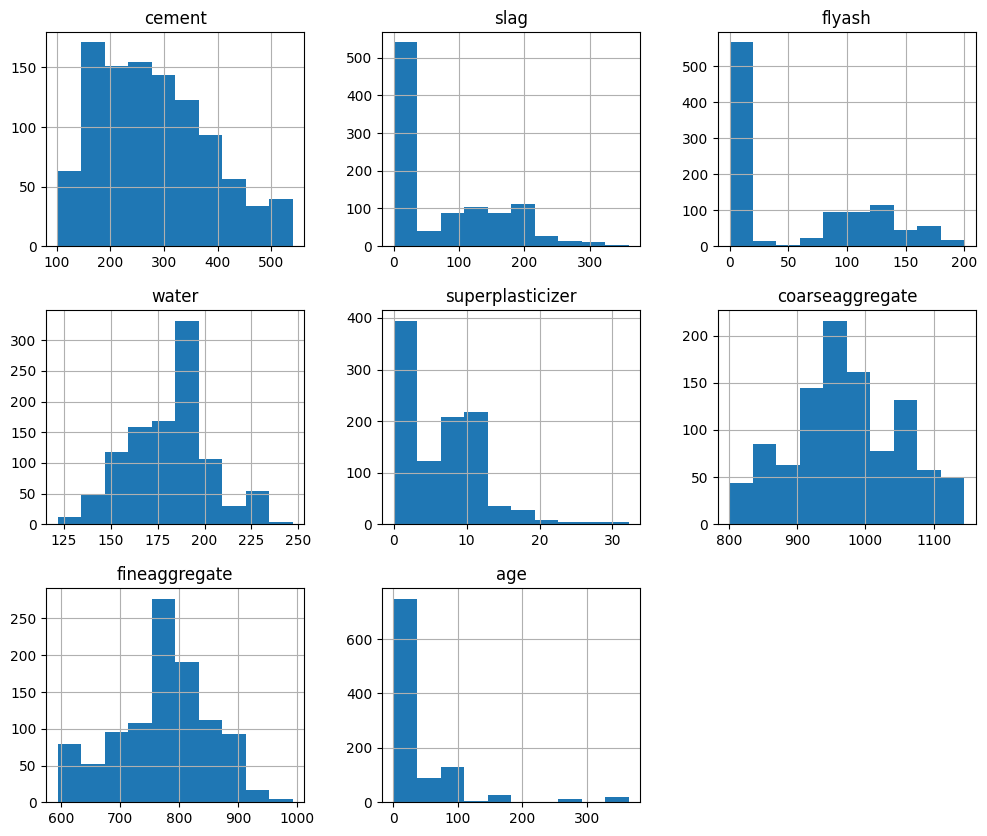

In [ ]:
new_cols = data.columns[:-1] # exclude the target variable concrete strength
data.hist(column=new_cols, figsize=(12, 10))

"""
 - Slag, superplasticizer, flyash, and age are heavily skewed to the right and contain many zeroes.
 - This might be the case because these are "optional" add-ons to the concrete mixes and are not 
  - as commonly-used or as fundamental/necessary as the other ingredients.
"""

Pearson correlation between csMPa and cement: 0.4978
Pearson correlation between csMPa and slag: 0.1348
Pearson correlation between csMPa and flyash: -0.1058
Pearson correlation between csMPa and water: -0.2896
Pearson correlation between csMPa and superplasticizer: 0.3661
Pearson correlation between csMPa and coarseaggregate: -0.1649
Pearson correlation between csMPa and fineaggregate: -0.1672
Pearson correlation between csMPa and age: 0.3289


'\n - Cement amount is most positively correlated with strength.\n - Water amount is most negatively correlated with strength.\n - These relationships make sense because cement makes concrete stronger and harder, and water makes it \n  - weaker because the mixture becomes looser, wetter, and more moist.\n'

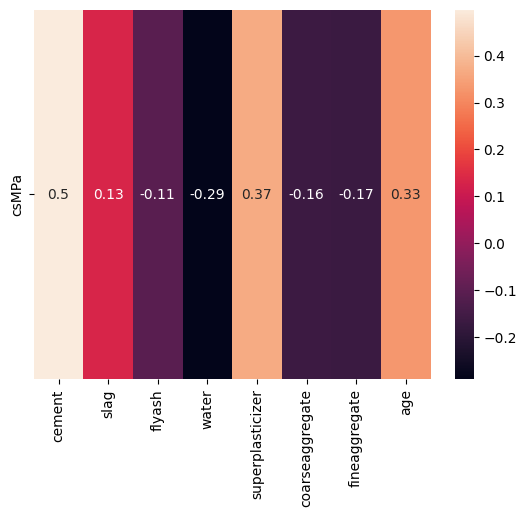

In [28]:
import math

# Pearson Correlation Matrix Calculation
pearson_coeffs = []
for col in data.columns[:-1]:  # Exclude the target variable
    a = np.corrcoef(data[col], data['csMPa'])[0, 1]
    pearson_coeffs.append(a)
    print(f"Pearson correlation between csMPa and {col}: {a:.4f}")

pearson_coeffs = np.array(pearson_coeffs).reshape(1, -1)  # Reshape for heatmap
sns.heatmap(pearson_coeffs, annot=True, xticklabels=data.columns[:-1], yticklabels=['csMPa'])

"""
 - Cement amount is most positively correlated with strength.
 - Water amount is most negatively correlated with strength.
 - These relationships make sense because cement makes concrete stronger and harder, and water makes it 
  - weaker because the mixture becomes looser, wetter, and more moist.
"""

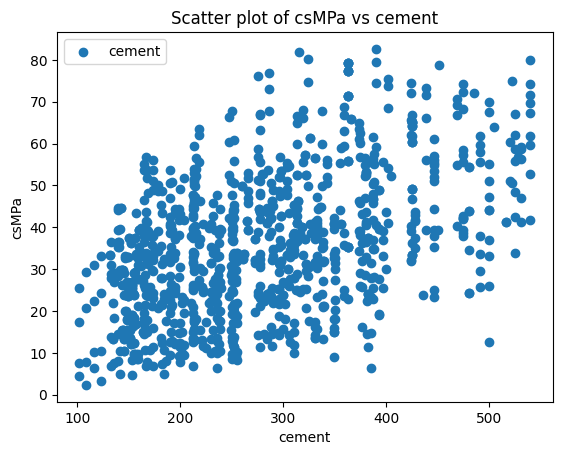

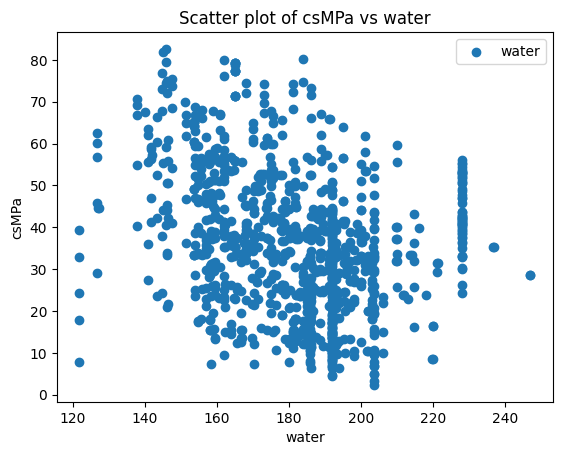

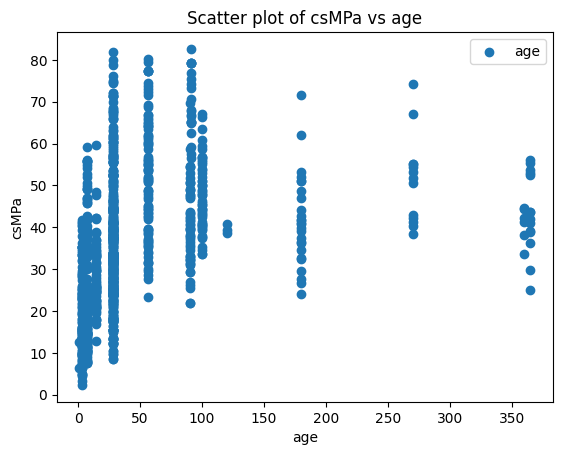

'\n- The relationships appear nonlinear, but there are positive correlations.\n'

In [ ]:
for col in ['cement', 'water', 'age']:  # Exclude the target variable
    plt.scatter(data[col], data['csMPa'], label=col)
    plt.xlabel(col)
    plt.ylabel('csMPa')
    plt.title(f'Scatter plot of csMPa vs {col}')
    plt.legend()
    plt.show()

"""
- The relationships appear nonlinear, but there are positive correlations, and a linear relationship
     - might be a reasonable approximation for these cases.
"""


In [48]:
# randomly split the data into 80% training and 20% testing sets
np.random.seed(42) 

training_data = data.sample(frac=0.8)  # Sample 80% of the data for training   
    # Note that this uses the "global seed" that we set as 42 above
    # This helps with reproducibility
    
testing_data = data.drop(training_data.index)  # Use the remaining 20% for testing
print("Number of samples in training set:", training_data.shape[0])
print("Number of samples in testing set:", testing_data.shape[0])

Number of samples in training set: 824
Number of samples in testing set: 206


In [ ]:
"""Why standardize the data?
Fitting linear regression directly on the raw features is problematic because the "slope"
for each feature's linear relationship will be much different from the others.
 - This means that it will be very difficult to do gradient descent due to the large
    differences in the scales of the slopes.
 - Standardizing the data brings these slopes much closer together than if they are
    left in their raw form, and this also allows for interpreting which features cause
    the most change easier (because they are all normalized).
"""

In [49]:
for col in data.columns[:-1]:  # Exclude the target variable
    mean = training_data[col].mean()
    std = training_data[col].std()
    
    training_data[col] = (training_data[col] - mean) / std
    testing_data[col] = (testing_data[col] - mean) / std

print("First 5 rows of the standardized training data:")
print(training_data.head())

"""
It would be incorrect to compute mean and variance on the combined train+test data because our model doesn't 
have (shouldn't have) access to the test data during training. The point of the test data is to 
evaluate whether we're overfitting or not, so using testing statistics makes our model worse 
and more likely to overfit later. 
"""

First 5 rows of the standardized training data:
       cement      slag    flyash     water  superplasticizer  \
31  -0.136386  0.493182 -0.857459  2.174267         -1.045332   
109  0.796535  1.384678 -0.857459 -0.740715          0.859627   
136  1.060187  1.384678 -0.857459 -1.618443          2.567522   
88   0.796535  1.384678 -0.857459 -0.740715          0.859627   
918 -1.304953 -0.861892  1.935831  0.973165          0.268433   

     coarseaggregate  fineaggregate       age  csMPa  
31         -0.511592      -1.315683  5.010859  52.91  
109        -0.350494      -0.257096 -0.600147  55.90  
136        -0.350494      -0.257096 -0.271009  74.50  
88         -0.350494      -0.257096 -0.662839  35.30  
918        -1.881562       1.139548 -0.271009  10.54  


"\nIt would be incorrect to compute mean and variance on the combined train+test data because our model doesn't \nhave (shouldn't have) access to the test data during training. The point of the test data is to \nevaluate whether we're overfitting or not, so using testing statistics makes our model worse \nand more likely to overfit later. \n"

In [ ]:
print("\n---- TRAINING DATA STATISTICS: ")
for col in data.columns[:-1]:  # Exclude the target variable
    mean = training_data[col].mean()
    std = training_data[col].std()
    print(f"After standardization, mean of {col}: {training_data[col].mean():.4f}, std of {col}: {training_data[col].std():.4f}")

print("\n---- TESTING DATA STATISTICS: ")

for col in data.columns[:-1]:  # Exclude the target variable
    test_mean = testing_data[col].mean()
    test_std = testing_data[col].std()
    print(f"After standardization, mean of {col} in test set: {test_mean:.4f}, std of {col} in test set: {test_std:.4f}")

"""
The test set statistics are NOT exactly 0 and 1 because to compute the mean and std that we 
used to normalize the dataset, we only used the training data. Therefore, on the training data,
this will cause the new mean and variance to be exactly 0 and 1, but on the test data, the mean
and variance will be close to, but not quite, 0 and 1 (they are approximately, but not exactly
the same as the training data).
"""


---- TRAINING DATA STATISTICS: 
After standardization, mean of cement: 0.0000, std of cement: 1.0000
After standardization, mean of slag: 0.0000, std of slag: 1.0000
After standardization, mean of flyash: 0.0000, std of flyash: 1.0000
After standardization, mean of water: -0.0000, std of water: 1.0000
After standardization, mean of superplasticizer: -0.0000, std of superplasticizer: 1.0000
After standardization, mean of coarseaggregate: -0.0000, std of coarseaggregate: 1.0000
After standardization, mean of fineaggregate: 0.0000, std of fineaggregate: 1.0000
After standardization, mean of age: -0.0000, std of age: 1.0000

---- TESTING DATA STATISTICS: 
After standardization, mean of cement in test set: 0.0505, std of cement in test set: 1.0471
After standardization, mean of slag in test set: 0.0824, std of slag in test set: 1.1222
After standardization, mean of flyash in test set: -0.0593, std of flyash in test set: 0.9943
After standardization, mean of water in test set: 0.1463, std o